In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

%matplotlib inline

In [2]:
fund = pd.read_csv("../data/processed/01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/05_category_inflows.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

transactions = pd.read_csv("../data/processed/clean_transactions.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

fig.write_image("../reports/nav_trend.png")

In [ ]:
--!0 selected NAV funds trend
selected = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841,  # Kotak Bluechip
    100016,
    100025,
    101206,
    101208,
    102885
]

nav10 = nav[nav["amfi_code"].isin(selected)]

fig = px.line(
    nav10,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (Selected 10 Funds)"
)

fig.show()

In [ ]:
--Average NAV fund values
avg_nav = (
    nav.groupby("date")["nav"]
       .mean()
       .reset_index()
)

fig = px.line(
    avg_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Trend (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-07-01",
    x1="2024-10-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction"
)

fig.show()

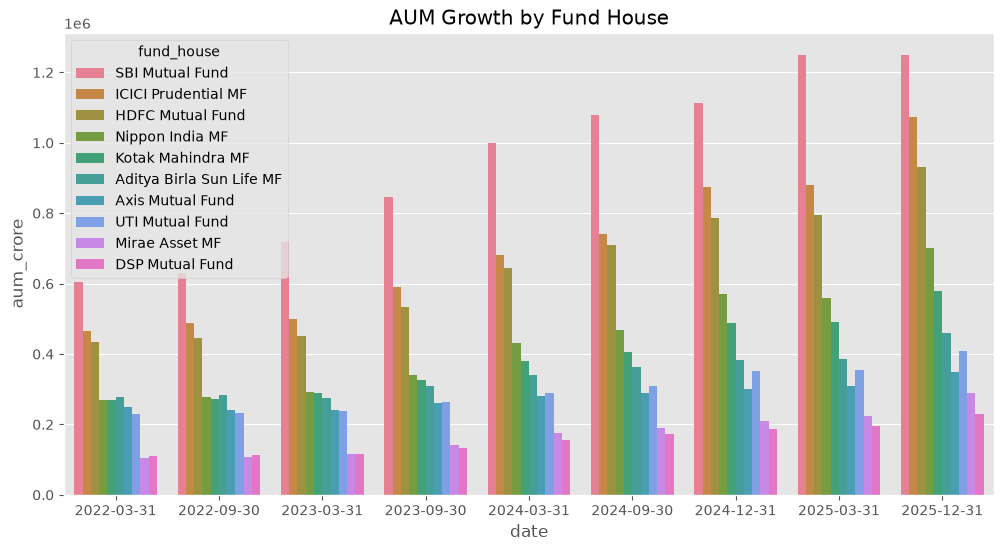

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.savefig("../reports/aum_growth.png")

plt.show()

In [11]:
sip["month"] = pd.to_datetime(sip["month"])
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow"
)

fig.show()

fig.write_image("../reports/sip_trend.png")

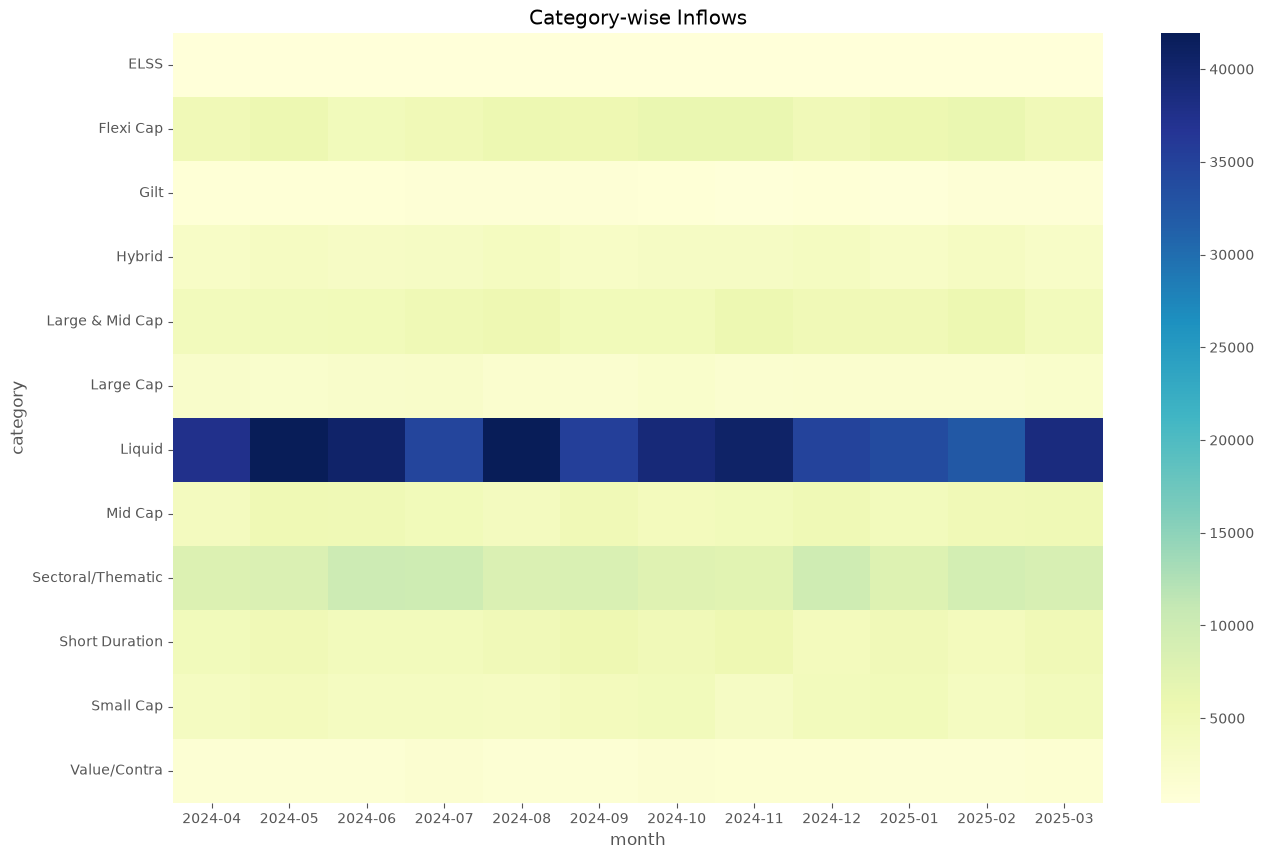

In [14]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(15,10))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Inflows")

plt.savefig("../reports/category_heatmap.png")

plt.show()

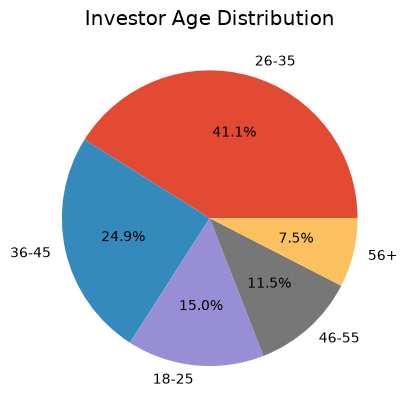

In [15]:
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.savefig("../reports/age_distribution.png")

plt.show()

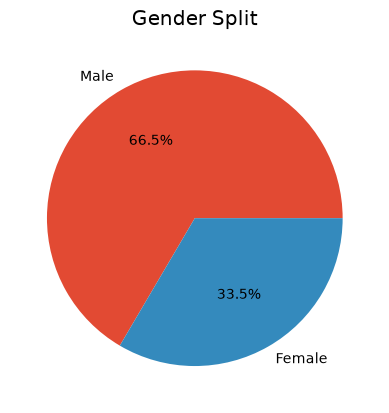

In [16]:
transactions["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Gender Split")

plt.savefig("../reports/gender_split.png")

plt.show()

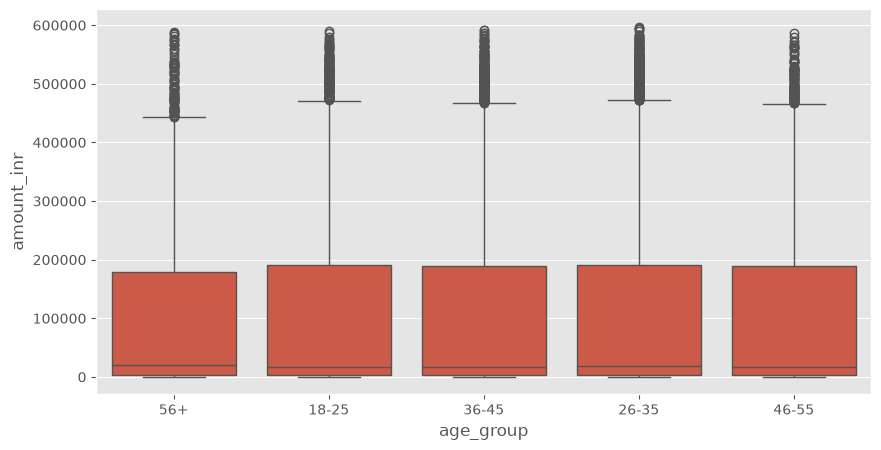

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.savefig("../reports/sip_boxplot.png")

plt.show()

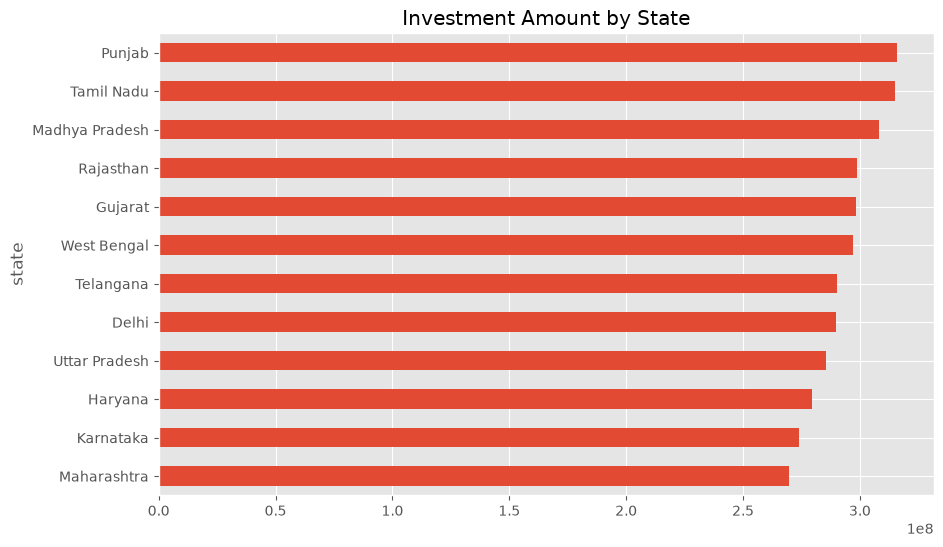

In [18]:
state = transactions.groupby("state")["amount_inr"].sum()

state.sort_values().plot.barh(figsize=(10,6))

plt.title("Investment Amount by State")

plt.savefig("../reports/state_distribution.png")

plt.show()

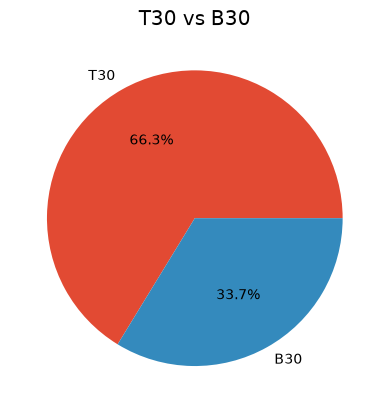

In [19]:
transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("T30 vs B30")

plt.savefig("../reports/city_tier.png")

plt.show()

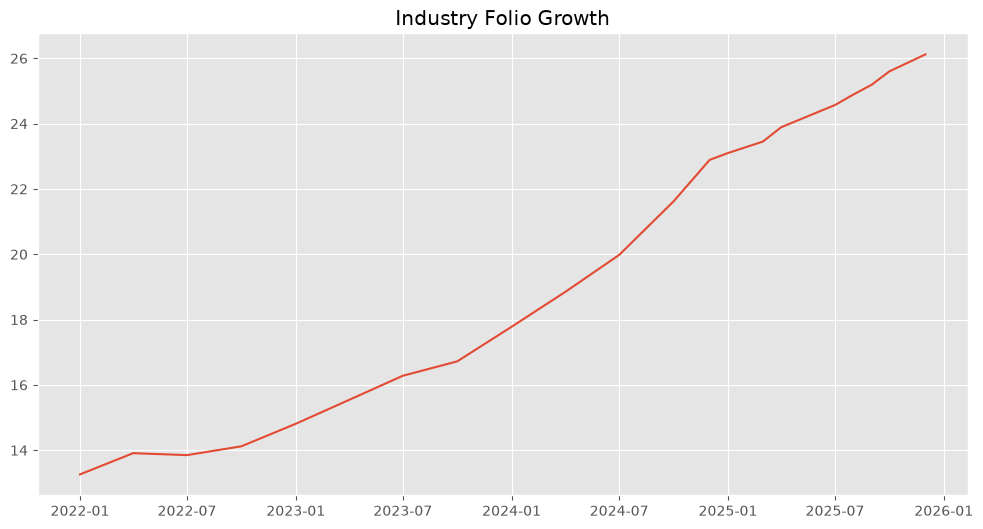

In [22]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.savefig("../reports/folio_growth.png")

plt.show()

In [21]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


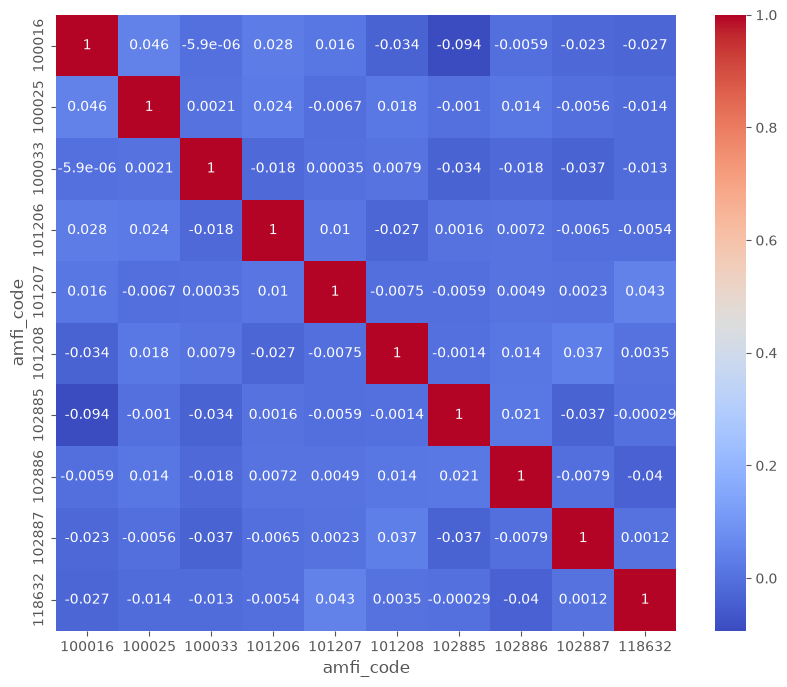

In [25]:
sample = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]
pivot = sample.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)
returns = pivot.pct_change()

corr = returns.corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.savefig("../reports/correlation.png")

plt.show()

In [26]:
sector = portfolio.groupby(
    "sector"
)["weight_pct"].sum()
fig = px.pie(
    names=sector.index,
    values=sector.values,
    hole=0.45,
    title="Sector Allocation"
)

fig.show()

fig.write_image("../reports/sector_donut.png")

1.NAV showed an overall upward trend from 2022–2026, with a noticeable rally during 2023.

2.SBI Mutual Fund maintained the highest AUM among all fund houses.

3.SIP inflows steadily increased and reached their highest level in late 2025.

4.Equity funds received the largest net inflows compared to other categories.

5.Investors aged 26–35 contributed the highest transaction volume.

6.Male investors represented a larger share of total investors.

7.T30 cities contributed a higher investment amount than B30 cities.

8.Industry folio counts nearly doubled over the analysis period.

9.Most selected large-cap funds showed a strong positive return correlation.

10.Financial Services and Information Technology had the highest portfolio allocation.